In [138]:
import pandas as pd
import numpy as np

In [139]:
ml_df = pd.read_csv(
    'final_project_dataset.csv',
    parse_dates=['date']
)

print(ml_df.shape)
print(ml_df[['date', 'target', 'sentiment_score']].head())

(132, 14)
        date  target  sentiment_score
0 2025-08-21       0                6
1 2025-08-20       1                8
2 2025-08-19       1                9
3 2025-08-18       0               20
4 2025-08-14       1                8


In [140]:
ml_df = ml_df.sort_values('date').reset_index(drop=True)

In [141]:
print(ml_df[['date', 'target', 'sentiment_score']].head())
print(ml_df[['date', 'target', 'sentiment_score']].tail())

        date  target  sentiment_score
0 2025-02-07       0               15
1 2025-02-10       0               -1
2 2025-02-11       0               -9
3 2025-02-12       0               30
4 2025-02-13       0                8
          date  target  sentiment_score
127 2025-08-14       1                8
128 2025-08-18       0               20
129 2025-08-19       1                9
130 2025-08-20       1                8
131 2025-08-21       0                6


In [142]:
ml_df['next_day_target'] = ml_df['target'].shift(-1)
print(
    ml_df[['date', 'target', 'next_day_target']].head(10)
)

        date  target  next_day_target
0 2025-02-07       0              0.0
1 2025-02-10       0              0.0
2 2025-02-11       0              0.0
3 2025-02-12       0              0.0
4 2025-02-13       0              0.0
5 2025-02-14       0              1.0
6 2025-02-17       1              0.0
7 2025-02-18       0              1.0
8 2025-02-19       1              1.0
9 2025-02-20       1              0.0


In [143]:
ml_df = ml_df.dropna(
    subset=['next_day_target']
)

ml_df['next_day_target'] = (
    ml_df['next_day_target'].astype(int)
)
print(ml_df.shape)
print(ml_df['next_day_target'].value_counts())
print(ml_df[['date', 'target', 'next_day_target']].tail())

(131, 15)
next_day_target
0    66
1    65
Name: count, dtype: int64
          date  target  next_day_target
126 2025-08-13       1                1
127 2025-08-14       1                0
128 2025-08-18       0                1
129 2025-08-19       1                1
130 2025-08-20       1                0


In [144]:
ml_df['sentiment_ma3'] = (
    ml_df['sentiment_score']
    .rolling(window=3)
    .mean()
)

ml_df['sentiment_ma7'] = (
    ml_df['sentiment_score']
    .rolling(window=7)
    .mean()
)

ml_df['sentiment_std3'] = (
    ml_df['sentiment_score']
    .rolling(window=3)
    .std()
)

print(
    ml_df[
        ['date',
         'sentiment_score',
         'sentiment_ma3',
         'sentiment_ma7',
         'sentiment_std3']
    ].head(10)
)

        date  sentiment_score  sentiment_ma3  sentiment_ma7  sentiment_std3
0 2025-02-07               15            NaN            NaN             NaN
1 2025-02-10               -1            NaN            NaN             NaN
2 2025-02-11               -9       1.666667            NaN       12.220202
3 2025-02-12               30       6.666667            NaN       20.599353
4 2025-02-13                8       9.666667            NaN       19.553346
5 2025-02-14               -7      10.333333            NaN       18.610033
6 2025-02-17                6       2.333333       6.000000        8.144528
7 2025-02-18                7       2.000000       4.857143        7.810250
8 2025-02-19                1       4.666667       5.142857        3.214550
9 2025-02-20               23      10.333333       9.714286       11.372481


In [145]:
ml_df['movement_lag1'] = ml_df['movement'].shift(1)
ml_df['movement_lag2'] = ml_df['movement'].shift(2)

print(
    ml_df[
        ['date',
         'movement',
         'movement_lag1',
         'movement_lag2']
    ].head(10)
)

        date  movement  movement_lag1  movement_lag2
0 2025-02-07    -89.55            NaN            NaN
1 2025-02-10   -162.20         -89.55            NaN
2 2025-02-11   -311.75        -162.20         -89.55
3 2025-02-12     -5.55        -311.75        -162.20
4 2025-02-13    -24.35          -5.55        -311.75
5 2025-02-14   -167.20         -24.35          -5.55
6 2025-02-17    149.60        -167.20         -24.35
7 2025-02-18    -18.35         149.60        -167.20
8 2025-02-19     85.65         -18.35         149.60
9 2025-02-20     92.05          85.65         -18.35


In [146]:
ml_df['volume_change'] = (
    ml_df['shares_traded'].pct_change()
)
print(
    ml_df[
        ['date',
         'shares_traded',
         'volume_change']
    ].head(10)
)

        date  shares_traded  volume_change
0 2025-02-07    368092482.0            NaN
1 2025-02-10    225529166.0      -0.387303
2 2025-02-11    267969979.0       0.188183
3 2025-02-12    279656513.0       0.043611
4 2025-02-13    265706855.0      -0.049881
5 2025-02-14    254479643.0      -0.042254
6 2025-02-17    207393944.0      -0.185027
7 2025-02-18    210616675.0       0.015539
8 2025-02-19    206999204.0      -0.017176
9 2025-02-20    240836647.0       0.163467


In [147]:
ml_df['high_low_spread'] = (
    (ml_df['high'] - ml_df['low'])
    / ml_df['open']
    * 100
)
feature_cols = [
    'sentiment_score',
    'sentiment_ma3',
    'sentiment_ma7',
    'sentiment_std3',
    'movement_lag1',
    'movement_lag2',
    'volume_change',
    'high_low_spread'
]

print(
    ml_df[
        ['date'] + feature_cols + ['next_day_target']
    ].head(10)
)

        date  sentiment_score  sentiment_ma3  sentiment_ma7  sentiment_std3  \
0 2025-02-07               15            NaN            NaN             NaN   
1 2025-02-10               -1            NaN            NaN             NaN   
2 2025-02-11               -9       1.666667            NaN       12.220202   
3 2025-02-12               30       6.666667            NaN       20.599353   
4 2025-02-13                8       9.666667            NaN       19.553346   
5 2025-02-14               -7      10.333333            NaN       18.610033   
6 2025-02-17                6       2.333333       6.000000        8.144528   
7 2025-02-18                7       2.000000       4.857143        7.810250   
8 2025-02-19                1       4.666667       5.142857        3.214550   
9 2025-02-20               23      10.333333       9.714286       11.372481   

   movement_lag1  movement_lag2  volume_change  high_low_spread  \
0            NaN            NaN            NaN         1.062602

In [148]:
print(ml_df[feature_cols].isnull().sum())

sentiment_score    0
sentiment_ma3      2
sentiment_ma7      6
sentiment_std3     2
movement_lag1      1
movement_lag2      2
volume_change      1
high_low_spread    0
dtype: int64


In [149]:
ml_df = ml_df.dropna(
    subset=feature_cols
).reset_index(drop=True)
print(ml_df.shape)
print(ml_df[feature_cols].isnull().sum())
print(ml_df[['date', 'next_day_target']].head())

(125, 22)
sentiment_score    0
sentiment_ma3      0
sentiment_ma7      0
sentiment_std3     0
movement_lag1      0
movement_lag2      0
volume_change      0
high_low_spread    0
dtype: int64
        date  next_day_target
0 2025-02-17                0
1 2025-02-18                1
2 2025-02-19                1
3 2025-02-20                0
4 2025-02-21                0


In [150]:
X = ml_df[feature_cols]
y = ml_df['next_day_target']

split_idx = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Split index:", split_idx)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:")
print(y_train.value_counts())

print("y_test:")
print(y_test.value_counts())

print("\nTrain dates:")
print(ml_df.iloc[:split_idx]['date'].min())
print(ml_df.iloc[:split_idx]['date'].max())

print("\nTest dates:")
print(ml_df.iloc[split_idx:]['date'].min())
print(ml_df.iloc[split_idx:]['date'].max())

Split index: 100
X_train: (100, 8)
X_test : (25, 8)
y_train:
next_day_target
1    53
0    47
Name: count, dtype: int64
y_test:
next_day_target
0    14
1    11
Name: count, dtype: int64

Train dates:
2025-02-17 00:00:00
2025-07-15 00:00:00

Test dates:
2025-07-16 00:00:00
2025-08-20 00:00:00


In [151]:
test_majority = y_test.value_counts().max() / len(y_test)

print("Test-set majority baseline:")
print(round(test_majority * 100, 2), "%")

Test-set majority baseline:
56.0 %


In [152]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [153]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

logreg_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression accuracy:")
print(round(logreg_accuracy * 100, 2), "%")

print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression accuracy:
44.0 %
              precision    recall  f1-score   support

           0       0.50      0.43      0.46        14
           1       0.38      0.45      0.42        11

    accuracy                           0.44        25
   macro avg       0.44      0.44      0.44        25
weighted avg       0.45      0.44      0.44        25

Confusion Matrix:
[[6 8]
 [6 5]]


In [154]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:")
print(round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy:
52.0 %


In [155]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.58      0.50      0.54        14
           1       0.46      0.55      0.50        11

    accuracy                           0.52        25
   macro avg       0.52      0.52      0.52        25
weighted avg       0.53      0.52      0.52        25



In [156]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Confusion Matrix:
[[7 7]
 [5 6]]


In [157]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

In [158]:
rf_base = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

In [159]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [160]:
print("Best parameters:")
print(grid_search.best_params_)

print()
print("Best cross-validation accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}

Best cross-validation accuracy:
51.25 %


In [161]:
best_rf = grid_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

print()
print("Tuned Random Forest test accuracy:")
print(round(tuned_rf_accuracy * 100, 2), "%")


Tuned Random Forest test accuracy:
44.0 %


In [162]:
results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Test Accuracy': [
        test_majority,
        logreg_accuracy,
        rf_accuracy,
        tuned_rf_accuracy
    ]
})

results['Test Accuracy (%)'] = (
    results['Test Accuracy'] * 100
).round(2)

print(results[['Model', 'Test Accuracy (%)']])

                 Model  Test Accuracy (%)
0    Majority Baseline               56.0
1  Logistic Regression               44.0
2        Random Forest               52.0
3  Tuned Random Forest               44.0


In [163]:
import xgboost
print(xgboost.__version__)

3.4.1


In [164]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost accuracy:")
print(round(xgb_accuracy * 100, 2), "%")

print(classification_report(y_test, xgb_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost accuracy:
40.0 %
              precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.36      0.45      0.40        11

    accuracy                           0.40        25
   macro avg       0.41      0.41      0.40        25
weighted avg       0.41      0.40      0.40        25

Confusion Matrix:
[[5 9]
 [6 5]]


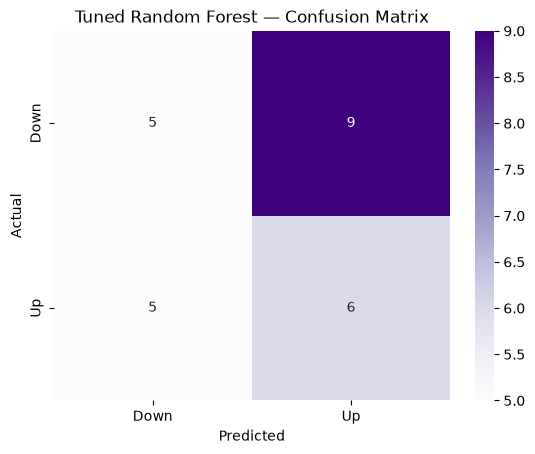

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_rf.predict(X_test)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Down', 'Up'],
    yticklabels=['Down', 'Up']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.show()

In [166]:
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)

test_df['pred'] = best_rf.predict(X_test)

print(
    test_df[
        ['date', 'close', 'pred', 'next_day_target']
    ].head(10)
)

        date     close  pred  next_day_target
0 2025-07-16  25212.05     0                0
1 2025-07-17  25111.45     1                0
2 2025-07-18  24968.40     1                1
3 2025-07-21  25090.70     1                0
4 2025-07-22  25060.90     0                1
5 2025-07-23  25219.90     1                0
6 2025-07-24  25062.10     0                0
7 2025-07-25  24837.00     0                0
8 2025-07-28  24680.90     1                1
9 2025-07-29  24821.10     1                0


In [167]:
price_df = pd.read_csv(
    'final_project_dataset.csv',
    parse_dates=['date']
)

price_df = (
    price_df
    .sort_values('date')
    .reset_index(drop=True)
)

price_df['next_close'] = price_df['close'].shift(-1)

test_df = test_df.merge(
    price_df[['date', 'next_close']],
    on='date',
    how='left'
)

test_df['next_day_return_pct'] = (
    (test_df['next_close'] - test_df['close'])
    / test_df['close']
    * 100
)

In [168]:
import numpy as np

test_df['strategy_return'] = np.where(
    test_df['pred'] == 1,
    test_df['next_day_return_pct'],
    0
)
test_df['cumulative_strategy'] = (
    1 + test_df['strategy_return'].fillna(0) / 100
).cumprod()

test_df['cumulative_market'] = (
    1 + test_df['next_day_return_pct'].fillna(0) / 100
).cumprod()

In [169]:
print(
    test_df[
        [
            'date',
            'close',
            'next_close',
            'pred',
            'next_day_return_pct',
            'strategy_return',
            'cumulative_strategy',
            'cumulative_market'
        ]
    ]
)

         date     close  next_close  pred  next_day_return_pct  \
0  2025-07-16  25212.05    25111.45     0            -0.399016   
1  2025-07-17  25111.45    24968.40     1            -0.569660   
2  2025-07-18  24968.40    25090.70     1             0.489819   
3  2025-07-21  25090.70    25060.90     1            -0.118769   
4  2025-07-22  25060.90    25219.90     0             0.634454   
5  2025-07-23  25219.90    25062.10     1            -0.625696   
6  2025-07-24  25062.10    24837.00     0            -0.898169   
7  2025-07-25  24837.00    24680.90     0            -0.628498   
8  2025-07-28  24680.90    24821.10     1             0.568051   
9  2025-07-29  24821.10    24855.05     1             0.136779   
10 2025-07-30  24855.05    24768.35     0            -0.348822   
11 2025-07-31  24768.35    24565.35     1            -0.819594   
12 2025-08-01  24565.35    24722.75     0             0.640740   
13 2025-08-04  24722.75    24649.55     1            -0.296084   
14 2025-08

In [170]:
print("Final strategy value:", 
      round(test_df['cumulative_strategy'].iloc[-1], 4))

print("Final market value:", 
      round(test_df['cumulative_market'].iloc[-1], 4))

Final strategy value: 0.9923
Final market value: 0.9949


In [171]:
print("Final strategy value:",
      round(test_df['cumulative_strategy'].iloc[-1], 6))

print("Final market value:",
      round(test_df['cumulative_market'].iloc[-1], 6))

Final strategy value: 0.992338
Final market value: 0.994911


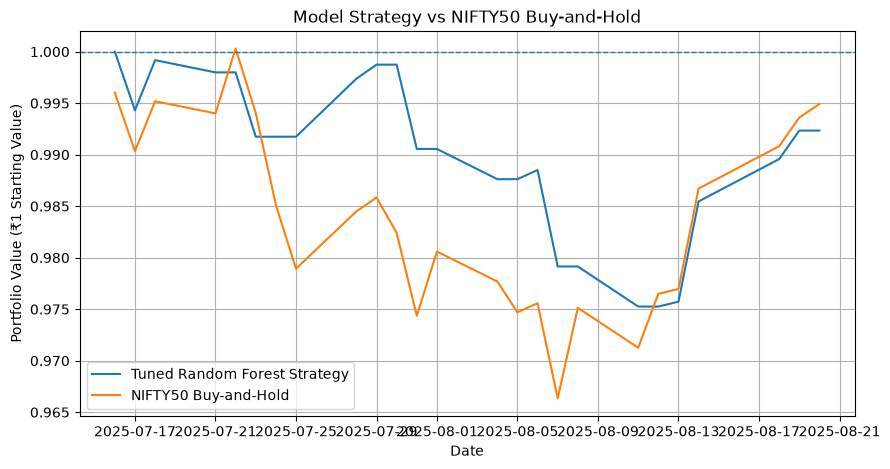

In [172]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_df['date'],
    test_df['cumulative_strategy'],
    label='Tuned Random Forest Strategy'
)

plt.plot(
    test_df['date'],
    test_df['cumulative_market'],
    label='NIFTY50 Buy-and-Hold'
)

plt.axhline(
    1.0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹1 Starting Value)')
plt.title('Model Strategy vs NIFTY50 Buy-and-Hold')
plt.legend()
plt.grid(True)
plt.show()

In [173]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols
)

print(importances.sort_values(ascending=False))

movement_lag1      0.182939
sentiment_ma7      0.174181
high_low_spread    0.150965
sentiment_std3     0.140246
sentiment_ma3      0.113807
movement_lag2      0.110487
sentiment_score    0.082579
volume_change      0.044796
dtype: float64


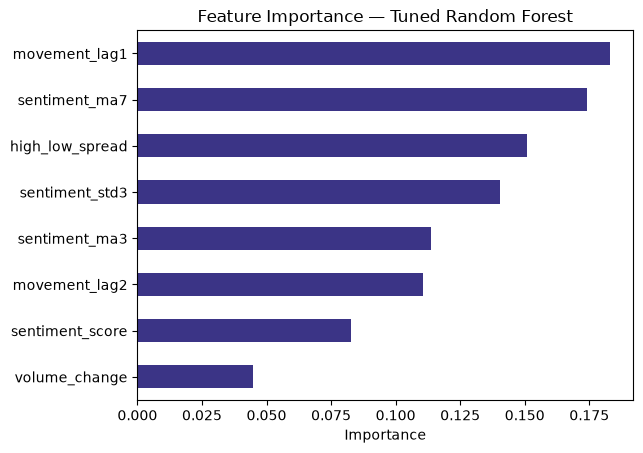

In [174]:
importances.sort_values().plot(
    kind='barh',
    color='#3B3486'
)

plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.show()

In [175]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance_df['Importance'] = (
    feature_importance_df['Importance']
    .round(6)
)

print(feature_importance_df)

           Feature  Importance
0    movement_lag1    0.182939
1    sentiment_ma7    0.174181
2  high_low_spread    0.150965
3   sentiment_std3    0.140246
4    sentiment_ma3    0.113807
5    movement_lag2    0.110487
6  sentiment_score    0.082579
7    volume_change    0.044796


In [176]:
final_model_results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest',
        'XGBoost'
    ],
    'Test Accuracy (%)': [
        test_majority * 100,
        logreg_accuracy * 100,
        rf_accuracy * 100,
        tuned_rf_accuracy * 100,
        xgb_accuracy * 100
    ]
})

final_model_results['Test Accuracy (%)'] = (
    final_model_results['Test Accuracy (%)']
    .round(2)
)

print(final_model_results)

                 Model  Test Accuracy (%)
0    Majority Baseline               56.0
1  Logistic Regression               44.0
2        Random Forest               52.0
3  Tuned Random Forest               44.0
4              XGBoost               40.0


In [177]:
strategy_final = test_df['cumulative_strategy'].iloc[-1]
market_final = test_df['cumulative_market'].iloc[-1]

strategy_return = (strategy_final - 1) * 100
market_return = (market_final - 1) * 100

backtest_summary = pd.DataFrame({
    'Strategy': [
        'Tuned Random Forest Strategy',
        'NIFTY50 Buy-and-Hold'
    ],
    'Final Value (₹1 Start)': [
        strategy_final,
        market_final
    ],
    'Total Return (%)': [
        strategy_return,
        market_return
    ]
})

backtest_summary['Final Value (₹1 Start)'] = (
    backtest_summary['Final Value (₹1 Start)'].round(6)
)

backtest_summary['Total Return (%)'] = (
    backtest_summary['Total Return (%)'].round(4)
)

print(backtest_summary)

                       Strategy  Final Value (₹1 Start)  Total Return (%)
0  Tuned Random Forest Strategy                0.992338           -0.7662
1          NIFTY50 Buy-and-Hold                0.994911           -0.5089


In [178]:
ml_df.to_csv(
    'part_b_ml_dataset.csv',
    index=False
)
print("Saved: part_b_ml_dataset.csv")

test_df.to_csv(
    'part_b_backtest_results.csv',
    index=False
)

print("Saved: part_b_backtest_results.csv")

final_model_results.to_csv(
    'part_b_model_comparison.csv',
    index=False
)

print("Saved: part_b_model_comparison.csv")

feature_importance_df.to_csv(
    'part_b_feature_importance.csv',
    index=False
)

print("Saved: part_b_feature_importance.csv")

Saved: part_b_ml_dataset.csv
Saved: part_b_backtest_results.csv
Saved: part_b_model_comparison.csv
Saved: part_b_feature_importance.csv


In [179]:
print("=" * 60)
print("PART B — FINAL RESULTS")
print("=" * 60)

print("\nDataset:")
print(f"Total ML observations: {len(ml_df)}")
print(f"Training observations: {len(X_train)}")
print(f"Test observations:     {len(X_test)}")

print("\nTest period:")
print(f"{ml_df.iloc[split_idx]['date'].date()} "
      f"to {ml_df.iloc[-1]['date'].date()}")

print("\nModel Accuracy:")
print(final_model_results.to_string(index=False))

print("\nTuned Random Forest:")
print("Best parameters:", grid_search.best_params_)
print("CV accuracy:",
      round(grid_search.best_score_ * 100, 2), "%")

print("\nBacktest:")
print(backtest_summary.to_string(index=False))

print("\nMost Important Features:")
print(feature_importance_df.to_string(index=False))

print("\nConclusion:")
print(
    "None of the tested ML models outperformed the "
    "56% majority-class baseline on the held-out test period."
)

print("=" * 60)

PART B — FINAL RESULTS

Dataset:
Total ML observations: 125
Training observations: 100
Test observations:     25

Test period:
2025-07-16 to 2025-08-20

Model Accuracy:
              Model  Test Accuracy (%)
  Majority Baseline               56.0
Logistic Regression               44.0
      Random Forest               52.0
Tuned Random Forest               44.0
            XGBoost               40.0

Tuned Random Forest:
Best parameters: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
CV accuracy: 51.25 %

Backtest:
                    Strategy  Final Value (₹1 Start)  Total Return (%)
Tuned Random Forest Strategy                0.992338           -0.7662
        NIFTY50 Buy-and-Hold                0.994911           -0.5089

Most Important Features:
        Feature  Importance
  movement_lag1    0.182939
  sentiment_ma7    0.174181
high_low_spread    0.150965
 sentiment_std3    0.140246
  sentiment_ma3    0.113807
  movement_lag2    0.110487
sentiment_score    0.082579
 